# 线性回归(Linear Regression)
线性回归是一种基本的监督学习算法，用于预测一个连续的目标变量（也称为因变量）与一个或多个自变量（也称为特征或解释变量）之间的关系。线性回归假设目标变量与自变量之间存在线性关系，即可以用一个线性方程来描述这种关系。

线性回归 (Linear Regression) 是一种用于预测连续值的最基本的机器学习算法，它假设目标变量 y 和特征变量 x 之间存在线性关系，并试图找到一条最佳拟合直线来描述这种关系。



## 线性回归的数学表达
线性回归的数学表达式可以表示为(单变量)：
$$y = \omega x + b$$
其中：
- $y$ 是目标变量（因变量）,预测值。
- $x$ 是特征变量。
- $\omega$ 是模型参数,即权重(斜率)。
- $b$ 是偏置项（截距）。

线性回归的目标是找到最佳的 $\omega$ 和 $b$，使得预测值 $y$ 与实际值之间的误差最小化。常用的误差度量是均方误差（Mean Squared Error, MSE），定义为：
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
其中 $n$ 是样本数量，$y_i$ 是实际值，$\hat{y}_i$ 是预测值。

我们的目标是最小化 MSE，以找到最佳的 $\omega$ 和 $b$。

## 如何求解线性回归?
求解线性回归模型的参数 $\omega$ 和 $b$ 可以通过以下方法实现：

### 1. 最小二乘法 (Ordinary Least Squares, OLS)
最小二乘法是一种常用的求解线性回归参数的方法。它通过求解以下方程来找到最佳的 $\omega$ 和 $b$：

最小二乘法的目标是最小化残差平方和(RSS) , 其公式为:
$$RSS = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

其中:
- $y_i$ 是实际值。
- $\hat{y}_i$ 是预测值 , 由线性回归模型 $\hat{y}_i = \omega x_i + b$ 给出。

通过最下化 RSS，我们可以得到以下正规方程 (上一个公式分别对 $\omega$ 和 $b$ 求导)。

$$
\begin{cases}
\omega \sum_{i=1}^{n} x_{i}^{2} + b \sum_{i=1}^{n} x_{i} = \sum_{i=1}^{n} x_{i}y_{i} \\
\omega \sum_{i=1}^{n} x_{i} + bn = \sum_{i=1}^{n} y_{i}
\end{cases}
$$

#### 矩阵形式

将正规方程写成矩阵形式，我们可以得到以下表达式：
$$\begin{bmatrix}\sum_{i=1}^{n} x_{i}^{2} & \sum_{i=1}^{n} x_{i} \\ \sum_{i=1}^{n} x_{i} & n\end{bmatrix} \begin{bmatrix}\omega \\ b\end{bmatrix} = \begin{bmatrix}\sum_{i=1}^{n} x_{i}y_{i} \\ \sum_{i=1}^{n} y_{i}\end{bmatrix}$$

#### 求解方法

通过求解上述线性方程组，我们可以得到 $\omega$ 和 $b$ 的值。通常使用矩阵的逆或伪逆来求解参数。
$$\begin{bmatrix}\omega \\ b\end{bmatrix} = \begin{bmatrix}\sum_{i=1}^{n} x_{i}^{2} & \sum_{i=1}^{n} x_{i} \\ \sum_{i=1}^{n} x_{i} & n\end{bmatrix}^{-1} \begin{bmatrix}\sum_{i=1}^{n} x_{i}y_{i} \\ \sum_{i=1}^{n} y_{i}\end{bmatrix}$$

### 2. 梯度下降法 (Gradient Descent)
梯度下降法的目标是最小化损失函数 $J(\omega, b)$, 对于线性回归，损失函数通常是均方误差 (MSE)。
$$J(\omega, b) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

其中
- $y_i$ 是实际值。
- $\hat{y}_i$ 是预测值 , 由线性回归模型 $\hat{y}_i = \omega x_i + b$ 给出。
- $n$ 是样本数量。

梯度是损失函数对参数的偏导数，表示损失函数在参数空间中的变化方向。对于线性回归，梯度可以表示为:
$$\nabla J(\omega, b) = \begin{bmatrix}\frac{\partial J}{\partial \omega} \\ \\ \frac{\partial J}{\partial b}\end{bmatrix} = \begin{bmatrix}-\frac{1}{n} \sum_{i=1}^{n} x_i (y_i - \hat{y}_i) \\\\ -\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)\end{bmatrix}$$

#### 参数更新规则
梯度下降法通过以下更新规则来迭代地调整参数 $\omega$ 和 $b$:
$$\begin{bmatrix}\omega \\ b\end{bmatrix} := \begin{bmatrix}\omega \\ b\end{bmatrix} - \alpha \nabla J(\omega, b)$$

其中 $\alpha$ 是学习率，控制每次更新的步长。

#### 梯度下降的步骤
- 1. 初始化参数 $\omega$ 和 $b$(通常设置为0或随机值)。
- 2. 计算预测值 $\hat{y}_i$。
- 3. 计算损失函数 $J(\omega, b)$。
- 4. 计算梯度 $\nabla J(\omega, b)$。
- 5. 更新参数 $\omega$ 和 $b$。
- 6. 重复步骤2-5，直到损失函数收敛或达到预设的迭代次数。

## 使用 python 实现线性回归
我们可以使用 Python 来实现线性回归模型。以下是一个简单的示例

In [20]:
# 1. 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

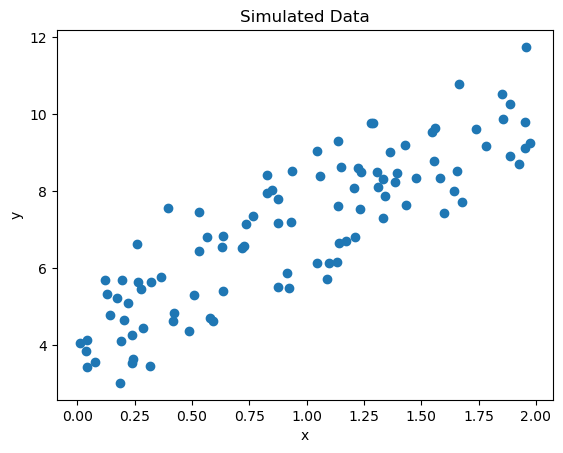

In [21]:
# 2. 生成模拟数据

# 生成一些随机数据
np.random.seed(0)
x = 2 * np.random.rand(100 , 1)
y = 4 + 3 * x + np.random.randn(100 , 1)


# 可视化数据
plt.scatter(x , y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Simulated Data')
plt.show()

In [ ]:
# 3. 创建线性回归模型并拟合数据
model = LinearRegression()

# 拟合模型
model.fit(x , y)

# 输出模型参数
print(f"斜率(w): {model.coef_[0][0]}")
print(f"截距(b): {model.intercept_[0]}")

斜率(w): [2.96846751]
截距(b): 4.222151077447232


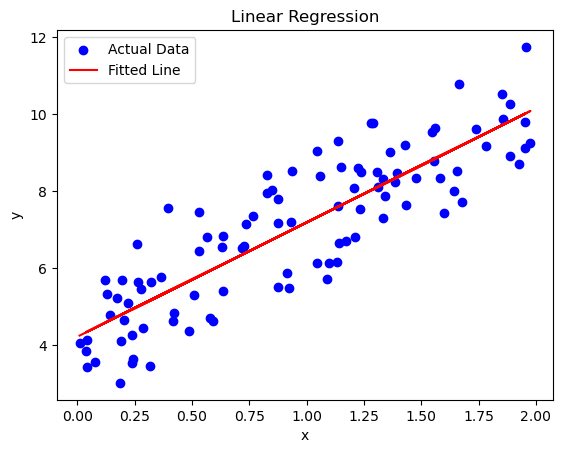

In [23]:
# 4. 预测
y_pred = model.predict(x)

# 可视化拟合结果
plt.scatter(x , y , color='blue' , label='Actual Data')
plt.plot(x , y_pred , color='red' , label='Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()
plt.show()

In [24]:
# 5. 评估模型
score = model.score(x , y)
print(f"模型得分: {score}")

模型得分: 0.7469629925504755


## 手动实现梯度下降法

斜率(w): 2.968467581470356
截距(b): 4.22215099769183


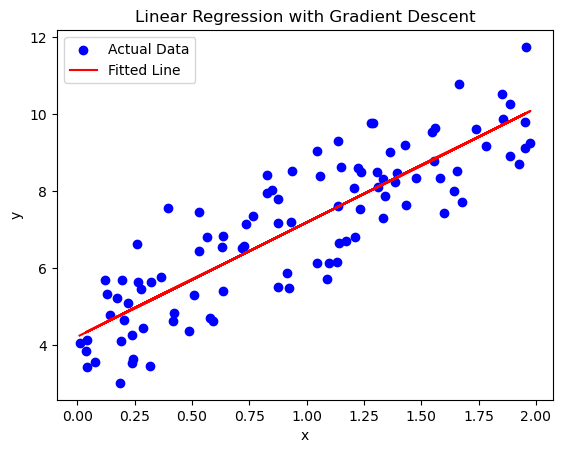

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# 生成一些随机数据
np.random.seed(0)
x = 2 * np.random.rand(100 , 1)
y = 4 + 3 * x + np.random.randn(100 , 1)

# 初始化参数
w = 0
b = 0
# 学习率
learning_rate = 0.1
# 迭代次数
n_iterations = 1000

# 梯度下降法
for i in range(n_iterations):
    y_pred = w * x + b
    dw = -(1 / len(x)) * np.sum((y - y_pred) * x)
    db = -(1 / len(x)) * np.sum(y - y_pred)
    w -= learning_rate * dw
    b -= learning_rate * db

# 输出模型参数
print(f"斜率(w): {w}")
print(f"截距(b): {b}")

# 可视化拟合结果
y_pred = w * x + b
plt.scatter(x , y , color='blue' , label='Actual Data')
plt.plot(x , y_pred , color='red' , label='Fitted Line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression with Gradient Descent')
plt.legend()
plt.show()